<a href="https://colab.research.google.com/github/Leeloo-Kikontwe/Codveda_Technologies_Machine_Learning_Internship/blob/main/Task5/Task1_Level3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [142]:
import pandas as pd
import numpy as np
import seaborn as sns
import re
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
nltk.download('punkt_tab')
from sklearn.feature_extraction.text import TfidfVectorizer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
path ='/content/drive/MyDrive/Data_Set_For_Task/Data_Set_For_Task/Sentiment_dataset.csv'
df = pd.read_csv(path)
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


EDA

In [ ]:
data = df.drop(['Unnamed: 0.1','Unnamed: 0'], axis=1)

In [ ]:
data.head()

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [ ]:
data.shape

(732, 13)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Text       732 non-null    object 
 1   Sentiment  732 non-null    object 
 2   Timestamp  732 non-null    object 
 3   User       732 non-null    object 
 4   Platform   732 non-null    object 
 5   Hashtags   732 non-null    object 
 6   Retweets   732 non-null    float64
 7   Likes      732 non-null    float64
 8   Country    732 non-null    object 
 9   Year       732 non-null    int64  
 10  Month      732 non-null    int64  
 11  Day        732 non-null    int64  
 12  Hour       732 non-null    int64  
dtypes: float64(2), int64(4), object(7)
memory usage: 74.5+ KB


In [ ]:
data.isnull().sum()

,0
Text,0
Sentiment,0
Timestamp,0
User,0
Platform,0
Hashtags,0
Retweets,0
Likes,0
Country,0
Year,0


In [ ]:
data.duplicated().sum()

np.int64(20)

In [ ]:
duplicated_val = data[data.duplicated(keep=False)]
print(duplicated_val.sort_values(by='Text').head(20))

                                                  Text        Sentiment  \
292   A compassionate rain, tears of empathy fallin...   Compassionate    
278   A compassionate rain, tears of empathy fallin...   Compassionate    
285   A free spirit soaring on the wings of dreams,...   Free-spirited    
271   A free spirit soaring on the wings of dreams,...   Free-spirited    
267   A playful escapade in the carnival of life, c...         Playful    
281   A playful escapade in the carnival of life, c...         Playful    
295   A playful escapade in the carnival of life, c...         Playful    
286   Bathed in the golden hues of gratefulness, a ...        Grateful    
272   Bathed in the golden hues of gratefulness, a ...        Grateful    
277   Charting a course through the waves of hopefu...         Hopeful    
291   Charting a course through the waves of hopefu...         Hopeful    
273   Confident strides in the dance of life, a bal...       Confident    
287   Confident strides i

In [ ]:
#Delete duplicated values because they are perfect duplicates (to prevent overfitting)
data.drop_duplicates(inplace=True)

In [ ]:
#For numerical features only
data.describe()

,Retweets,Likes,Year,Month,Day,Hour
count,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000
mean,21.542135,42.966292,2020.476124,6.108146,15.514045,15.592697
std,7.124840,14.215995,2.828326,3.406099,8.444895,4.062778
min,5.000000,10.000000,2010.000000,1.000000,1.000000,0.000000
25%,17.750000,34.750000,2019.000000,3.000000,10.000000,13.000000
50%,22.000000,43.000000,2021.000000,6.000000,15.000000,16.000000
75%,25.000000,50.000000,2023.000000,9.000000,22.000000,19.000000
max,40.000000,80.000000,2023.000000,12.000000,31.000000,23.000000


In [ ]:
#For categorical features only
data.describe(include = "O")

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Country
count,712,712,712,712,712,712,712
unique,707,279,683,685,4,697,115
top,Shattered dreams lie on the floor like fragme...,Positive,2019-04-05 17:30:00,WindWhisperer,Instagram,#Frustrated #MosaicOfDisappointment,USA
freq,2,44,3,2,252,2,59


CHECK FOR DATA IMBALANCE

In [ ]:
data['Platform'].value_counts()

,count
Platform,
Instagram,252
Facebook,224
Twitter,122
Twitter,114


In [ ]:
data['Sentiment'].value_counts()

,count
Sentiment,
Positive,44
Joy,42
Excitement,32
Neutral,14
Happy,14
...,...
Vibrancy,1
Culinary Adventure,1
Mesmerizing,1


In [ ]:
data['Country'].value_counts()

,count
Country,
USA,59
USA,51
UK,49
Canada,44
Australia,36
...,...
Ireland,1
Scotland,1
Kenya,1


DATA VISUALISATION

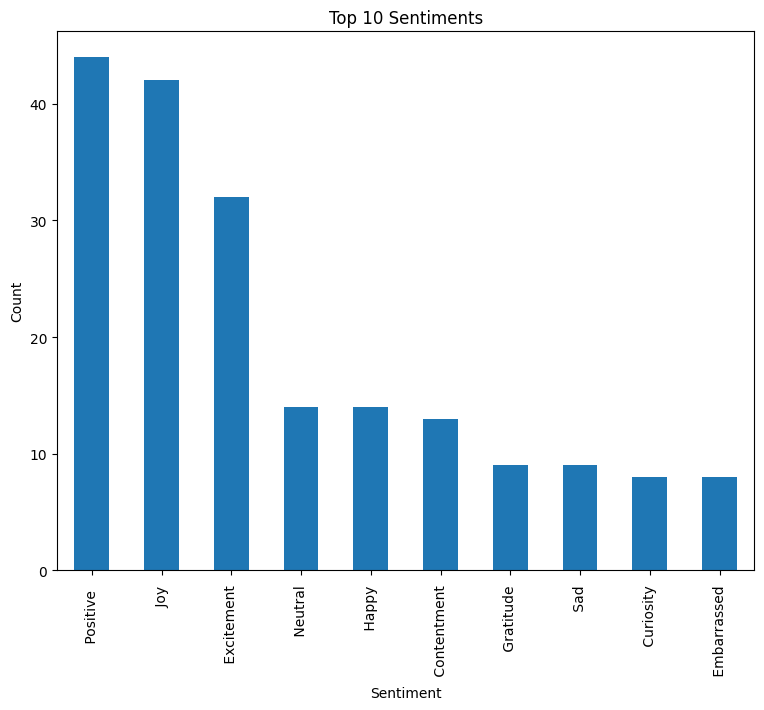

In [ ]:
plt.figure(figsize=(9,7))
data['Sentiment'].value_counts().nlargest(10).plot(kind='bar')
plt.title('Top 10 Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

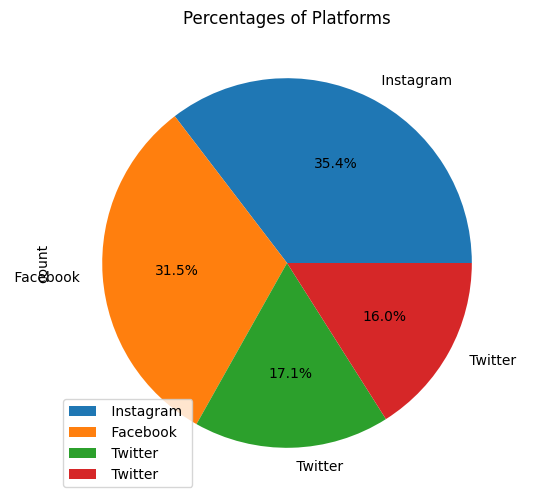

In [ ]:
plt.figure(figsize=(8,6))
data['Platform'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Percentages of Platforms')
plt.legend()
plt.show()

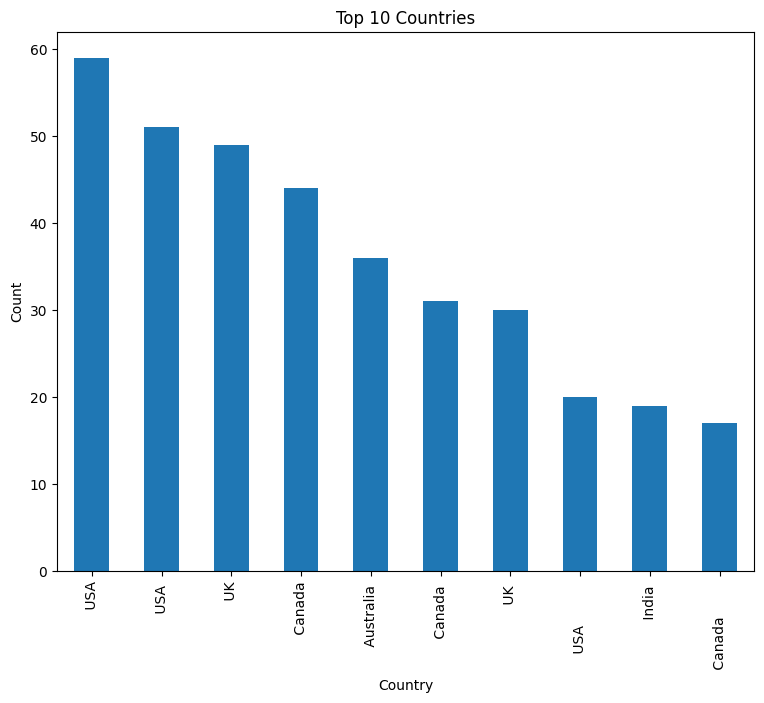

In [ ]:
plt.figure(figsize=(9,7))
data['Country'].value_counts().nlargest(10).plot(kind='bar')
plt.title('Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Count')
plt.show()

In [ ]:
print(data[['Likes','Retweets', 'Hour']].describe())

            Likes    Retweets        Hour
count  712.000000  712.000000  712.000000
mean    42.966292   21.542135   15.592697
std     14.215995    7.124840    4.062778
min     10.000000    5.000000    0.000000
25%     34.750000   17.750000   13.000000
50%     43.000000   22.000000   16.000000
75%     50.000000   25.000000   19.000000
max     80.000000   40.000000   23.000000


In [ ]:
print(data['Hour'].value_counts().head(5))

Hour
14    92
19    74
16    69
18    63
20    49
Name: count, dtype: int64


GROUPBY

In [ ]:
data.groupby('Platform')['Likes'].mean()

,Likes
Platform,
Facebook,41.915179
Instagram,45.138889
Twitter,45.680328
Twitter,37.324561


In [ ]:
data.groupby('Sentiment')[['Likes','Retweets']].mean().sort_values(by='Likes', ascending = False)

,Likes,Retweets
Sentiment,,
Wonder,80.0,40.000000
Wonder,80.0,40.000000
Motivation,80.0,40.000000
Mesmerizing,80.0,40.000000
Anticipation,80.0,40.000000
...,...,...
Helplessness,15.0,8.000000
Jealousy,15.0,8.000000
Despair,15.0,7.500000


In [ ]:
data.groupby('Country')['Likes'].mean().sort_values(ascending=False)

,Likes
Country,
India,80.000000
South Africa,80.000000
Belgium,70.000000
Japan,70.000000
Netherlands,70.000000
...,...
Canada,25.000000
Australia,24.200000
Canada,21.666667


In [ ]:
data.groupby('Sentiment')['Hashtags'].value_counts().sort_values(ascending=False)

Sentiment         Hashtags                                     
Joy               #TimelessTunes #SeniorJazz                       2
Love              #Love #SpreadLove                                2
Confusion         #Confusion #ThoughtLabyrinth                     2
Awe               #Awe #ArchitecturalGrandeur                      2
Compassionate     #Compassionate #TearsOfEmpathy                   2
                                                                  ..
Envy              #Envy #Desire                                    1
                  #Envy #Success                                   1
Euphoria          #Euphoria #ArianaGrande                          1
Euphoria          #Euphoria #PuzzleCompletion                      1
Enthusiasm        #Enthusiasm #HomeImprovement                     1
Name: count, Length: 702, dtype: int64

TEXT CLEANING AND PREPROCESSING

In [ ]:
#TRANSFORMING TIMESTAMP INTO NUMERIC COLUMNS
data['Timestamp']= pd.to_datetime(data['Timestamp'])
data['Day'] = data['Timestamp'].dt.day
data['Month'] = data['Timestamp'].dt.month
data['Year'] = data['Timestamp'].dt.year
data['Hour'] = data['Timestamp'].dt.hour

In [ ]:
#DELETE TIMESTAMP TO AVOID DATA REDUNDANCY
data.drop(['Timestamp'], axis = 1, inplace=True)

In [ ]:
#Delete user because it is not non-essential
data.drop(['User'], axis = 1, inplace=True)

In [ ]:
#DELETING INVISIBLE SPACES IN CATEGORICAL FEATURES
data['Text'] = data['Text'].str.strip()
data['Sentiment'] = data['Sentiment'].str.strip()
data['Platform'] = data['Platform'].str.strip()
data['Hashtags'] = data['Hashtags'].str.strip()
data['Country'] = data['Country'].str.strip()

In [ ]:
#Generalizing different sentiments
sia = SentimentIntensityAnalyzer()

all_sentiment_words = data['Sentiment'].unique().tolist()

sentiment_mapping = {}

for word in all_sentiment_words:
  score = sia.polarity_scores(str(word))['compound']
  if score >= 0.05:
    group = "Positive"
  elif score <= -0.05:
    group = 'Negative'
  else:
    group = 'Neutral'

  sentiment_mapping[word] = group

data['Sentiment_Grouped'] = data['Sentiment'].map(sentiment_mapping)

In [ ]:
data['Sentiment_Grouped'].value_counts()

,count
Sentiment_Grouped,
Positive,361
Negative,182
Neutral,169


In [ ]:
neu_words = [word for word, group in sentiment_mapping.items() if group =='Neutral']
pos_words = [word for word, group in sentiment_mapping.items() if group == 'Positive']
neg_words = [word for word, group in sentiment_mapping.items() if group == 'Negative']

print('Neutral words:\n',neu_words,'\n')
print('Positive words:\n',pos_words,'\n')
print('Negative words:\n',neg_words,'\n')

Neutral words:
 ['Neutral', 'Awe', 'Serenity', 'Empowerment', 'Arousal', 'Fulfillment', 'Reverence', 'Curiosity', 'Nostalgia', 'Ambivalence', 'Zest', 'Free-spirited', 'Apprehensive', 'Dismissive', 'Contemplation', 'JoyfulReunion', 'Reflection', 'Accomplishment', 'Wonderment', 'Enchantment', 'Intrigue', 'PlayfulJoy', 'Mindfulness', 'DreamChaser', 'Whimsy', 'Wonder', 'Rejuvenation', 'Melodic', 'FestiveJoy', 'InnerJourney', 'Dazzle', 'Adrenaline', 'ArtisticBurst', 'CulinaryOdyssey', 'Resilience', 'Immersion', 'EmotionalStorm', 'LostLove', 'Desolation', 'Heartache', 'Solitude', 'Captivation', 'Emotion', 'Celebration', 'Colorful', 'Hypnotic', 'Connection', 'Iconic', 'Journey', 'Touched', 'Suspense', 'Renewed Effort', 'Miscalculation', 'Solace', 'Breakthrough', 'Envisioning History', 'Imagination', 'Vibrancy', 'Mesmerizing', 'Winter Magic', 'Celestial Wonder', 'Whispers of the Past', 'Mischievous'] 

Positive words:
 ['Positive', 'Happiness', 'Joy', 'Love', 'Amusement', 'Enjoyment', 'Admirat

In [ ]:
#Make corrections
corr_positives = ['Awe', 'Serenity', 'Empowerment', 'Fulfillment', 'Reverence', 'Zest', 'Free-spirited', 'Accomplishment', 'Wonderment', 'Enchantment', 'PlayfulJoy', 'Mindfulness', 'Whimsy', 'Wonder', 'Rejuvenation', 'FestiveJoy', 'Dazzle', 'Adrenaline', 'Resilience', 'Celebration', 'Connection', 'Solace', 'Breakthrough', 'Vibrancy', 'Mesmerizing', 'Winter Magic', 'Celestial Wonder']
corr_negatives = ['Yearning','Desolation', 'Heartache', 'Solitude', 'LostLove', 'Overwhelmed', 'EmotionalStorm', 'Apprehensive', 'Dismissive']

for word in corr_positives:
  sentiment_mapping[word] = 'Positive'

for word in corr_negatives:
  sentiment_mapping[word] = 'Negative'

data['Sentiment_Grouped'] = data['Sentiment'].map(sentiment_mapping)

In [ ]:
data[['Sentiment', 'Sentiment_Grouped']].sample(15)

,Sentiment,Sentiment_Grouped
589,Joy,Positive
192,Jealousy,Negative
69,Bitter,Negative
392,FestiveJoy,Positive
600,Curiosity,Neutral
632,Gratitude,Positive
435,Exhaustion,Negative
16,Positive,Positive
80,Happiness,Positive
398,Adrenaline,Positive


In [ ]:
#Clean the 'Text' column
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def Clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https\S+', "", text)
    text = re.sub(r'@\w+', "", text)
    text = re.sub(r'#', "", text)
    text = re.sub(r'[^a-z\s]', "", text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords and stemming
    proc_tokens = [stemmer.stem(w) for w in tokens if w not in stop_words]
    return " ".join(proc_tokens).strip()

data['Clean_Text'] = data['Text'].apply(Clean_text)

# Merge with Hashtags
data['Clean_Hashtags'] = data['Hashtags'].fillna('') \
    .str.lower() \
    .str.replace(r'#', '', regex=True) \
    .str.replace(r'[^a-z\s]', '', regex=True) \
    .str.strip()

data['Final_Text'] = data['Clean_Text'] + ' ' + data['Clean_Hashtags'].str.strip()


In [153]:
data['Sentiment_Grouped'].value_counts()

,count
Sentiment_Grouped,
2,425
0,201
1,86


ENCODE CATEGORICAL FEATURES

In [ ]:
le = LabelEncoder()
data['Sentiment_Grouped'] = le.fit_transform(data['Sentiment_Grouped'])

SPLIT TRAINING AND TEST DATA

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(data['Final_Text'], data['Sentiment_Grouped'], test_size=0.2, random_state=42)


VECTORIZATION

In [ ]:
tfidf_vec = TfidfVectorizer()

#Fit and transform text
X_train_vec = tfidf_vec.fit_transform(x_train)
#transform
X_test_vec = tfidf_vec.transform(x_test)

BUILD AND TRAIN THE MODEL

In [138]:
model = RandomForestClassifier(n_estimators = 150, max_depth=5, min_samples_split=5, class_weight='balanced', random_state=42)
model.fit(X_train_vec, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=5,
                       min_samples_split=5, n_estimators=150, random_state=42)

PREDICTION

In [139]:
y_pred = model.predict(X_test_vec)

In [140]:
#Evaluation
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.73      0.80        44
           1       0.71      0.25      0.37        20
           2       0.76      0.96      0.85        79

    accuracy                           0.79       143
   macro avg       0.79      0.65      0.67       143
weighted avg       0.79      0.79      0.77       143



Note: The low recall is primarily due to the limited size of the dataset (86 samples).

MOST IMPORTANT FEATURES

In [147]:
importances = model.feature_importances_
words = tfidf_vec.get_feature_names_out()

feature_importance_df = pd.DataFrame({'Word': words, 'Importance': importances})
top_20 = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)
print(top_20)

             Word  Importance
1497    nostalgia    0.039754
504     curiosity    0.034815
503        curios    0.033310
744        explor    0.026570
1516          old    0.023547
826          flip    0.020832
1305         lost    0.017050
565       despair    0.014948
295        caught    0.014727
421      conflict    0.014512
1151     indiffer    0.014250
56    ambivalence    0.013943
1464        natur    0.013085
662          emot    0.012927
55        ambival    0.012896
1985        skill    0.011843
1554         pain    0.011734
1297   loneliness    0.010581
1481          new    0.010007
2340  uncertainti    0.009765


<Axes: xlabel='Importance', ylabel='Word'>

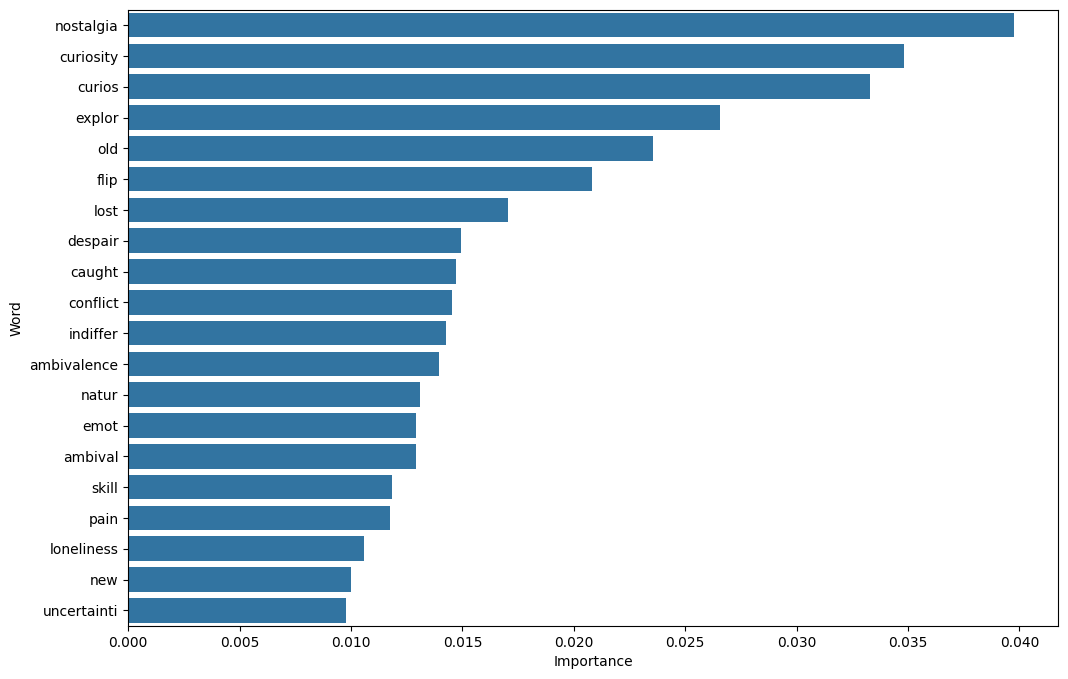

In [152]:
plt.figure(figsize=(12,8))
sns.barplot(x='Importance', y='Word', data=top_20)